# Appendix - VitalGuard: Real-Time Wearable Stress & Affect Detection System

**AAI-530 - Data Analytics and Internet of Things**

This notebook implements and compares three machine learning approaches for stress detection using the WESAD (Wearable Stress and Affect Detection) dataset:
- **1D-CNN**: Convolutional Neural Network for temporal pattern recognition
- **LSTM**: Long Short-Term Memory network for sequence modeling
- **XGBoost**: Gradient boosting with engineered features

---

## Table of Contents

1. [Environment Setup](#1.-Environment-Setup)
2. [Data Import & Extraction](#2.-Data-Import-&-Extraction)
3. [1D-CNN Implementation](#3.-1D-CNN-Implementation)
4. [LSTM Implementation](#4.-LSTM-Implementation)
5. [XGBoost Implementation](#5.-XGBoost-Implementation)
6. [Results & Comparison](#6.-Results-&-Comparison)

---

### 1.1 Import Required Libraries

Import all necessary libraries for data processing, visualization, and model building.

In [11]:
import os
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import pickle

from typing import Any
from scipy.signal import resample
from imblearn.over_sampling import RandomOverSampler
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow import keras
from keras.utils import to_categorical
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    balanced_accuracy_score, 
    precision_recall_fscore_support, 
    roc_curve, 
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)


### 1.2 Helper function

Setup helper functions used across models.

In [2]:
def load_subject_pickle(pkl_path: str) -> dict[str, Any]:
    """Load a subject's pickle file containing raw sensor data.
    
    Args:
        pkl_path: Path to the pickle file to load.
        
    Returns:
        Dictionary containing subject data with 'signal' and 'label' keys.
        The 'signal' key contains physiological sensor readings (ECG, EDA, 
        Respiration, Temperature, EMG, Accelerometer). The 'label' key 
        contains ground truth stress annotations.
    """
    with open(pkl_path, 'rb') as f:
        data = pickle.load(f, encoding='latin1')

    return data


---

## 2. Data Import & Extraction

### 2.1 Extract WESAD Dataset

Extract the compressed WESAD dataset. **Note:** This step only needs to be run once.

In [3]:
# Define paths using your local structure
COMPRESSED_DATASET_PATH = 'DATA/COMPRESSED_DATASET/WESAD.ZIP'
EXTRACT_PATH = 'data/'

if os.path.exists(COMPRESSED_DATASET_PATH):
    with zipfile.ZipFile(COMPRESSED_DATASET_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_PATH)
    print(f"Extraction complete! Files are in: {EXTRACT_PATH}")
else:
    print("Zip file not found. Check the path again.")


Extraction complete! Files are in: data/


---

## 3. 1D-CNN Implementation

### 3.1 Configuration Parameters

Define all hyperparameters and data split for the 1D-CNN model.

In [4]:
# Data Settings
DATA_PATH = '1d-cnn/aligned_wrist_data_64Hz_v1.csv'
if not os.path.exists(DATA_PATH):
    DATA_PATH = os.path.join(os.getcwd(), 'aligned_wrist_data_64Hz_v1.csv')

WINDOW_SIZE_SEC = 30       # 30-second windows (shorter = more windows, esp. with sparse labels)
SAMPLING_RATE = 64         # 64 Hz
WINDOW_LENGTH = WINDOW_SIZE_SEC * SAMPLING_RATE  # 1920 samples
STRIDE = WINDOW_LENGTH // 2  # 50% Overlap

# Window label threshold: require at least this fraction of non-(-1) labels (0.2 = 20%)
# Lower = more windows but noisier; higher = fewer but purer windows
MIN_VALID_LABEL_RATIO = 0.2

# Classification: 'binary' = stress vs non-stress (0,1), '3class' = baseline/stress/amusement (0,1,2)
N_CLASSES = 2  # 2 = binary, 3 = 3-class

# Training Settings
BATCH_SIZE = 16            # Smaller batch for limited data
EPOCHS = 80                # Use early stopping; max epochs
LEARNING_RATE = 0.001
USE_CLASS_WEIGHTS = True   # Handle class imbalance
USE_OVERSAMPLING = True    # Oversample minority class when possible

# Early Stopping
EARLY_STOPPING_PATIENCE = 15

# The 11/2/2 Split (Hardcoded for reproducibility)
TRAIN_SUBJECTS = ['S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 'S10', 'S11', 'S13']
VAL_SUBJECTS   = ['S14', 'S15']
TEST_SUBJECTS  = ['S16', 'S17']


### 3.2 Data Loading & Labeling

Load aligned BVP/EDA data and process labels for binary or 3-class classification.

In [5]:
def load_and_label_data(filepath):
    """
    Loads aligned BVP/EDA data. Uses real labels if 'label' column exists
    (0=baseline, 1=stress, 2=amusement, -1=other). Otherwise generates fallback labels.
    """
    if not os.path.exists(filepath):
        raise FileNotFoundError(f"Data file not found: {filepath}\n(Unzip aligned_wrist_data_64Hz.csv.zip if needed)")
    print("Loading data...")
    df = pd.read_csv(filepath)

    if 'label' in df.columns:
        print("Using real labels from CSV. Distribution:")
        print(df['label'].value_counts().sort_index())
        # Ensure int type
        df['label'] = df['label'].astype(int)
    else:
        print("No 'label' column found. Using fallback (first half=baseline, second half=stress)...")
        df['label'] = 0
        for sub in df['subject'].unique():
            sub_mask = df['subject'] == sub
            max_time = df.loc[sub_mask, 'time_sec'].max()
            df.loc[sub_mask & (df['time_sec'] > max_time / 2), 'label'] = 1

    return df


### 3.3 Preprocessing & Windowing

Create fixed-length windows from continuous sensor data with Z-score normalization per subject.

In [6]:
def _window_label(window_labels, n_classes, min_valid_ratio=0.2):
    """
    Majority vote for window. For 2-class: 0,2->0 (non-stress), 1->1 (stress).
    Skip windows where fewer than min_valid_ratio of samples have valid labels (non -1).
    """
    valid = window_labels[window_labels >= 0]  # exclude -1
    if len(valid) < len(window_labels) * min_valid_ratio:
        return None
    if n_classes == 2:
        # Map 2 (amusement) -> 0 (non-stress)
        valid = np.where(valid == 2, 0, valid)
        valid = valid[valid <= 1]  # keep only 0,1
        if len(valid) == 0:
            return None
    counts = np.bincount(valid.astype(int), minlength=n_classes)
    return int(np.argmax(counts))

def create_windows(df, subjects, n_classes=2, min_valid_ratio=None):
    """
    Slices data into fixed-length windows. Normalizes per subject (Z-Score).
    For 2-class: 0=non-stress (baseline+amusement), 1=stress.
    """
    if min_valid_ratio is None:
        min_valid_ratio = MIN_VALID_LABEL_RATIO
    X_windows, y_windows = [], []

    for sub in subjects:
        sub_df = df[df['subject'] == sub].copy()
        if sub_df.empty:
            continue

        scaler = StandardScaler()
        sub_df[['bvp', 'eda']] = scaler.fit_transform(sub_df[['bvp', 'eda']])
        data_arr = sub_df[['bvp', 'eda']].values
        label_arr = sub_df['label'].values
        num_samples = len(data_arr)

        for start in range(0, num_samples - WINDOW_LENGTH, STRIDE):
            end = start + WINDOW_LENGTH
            window_data = data_arr[start:end]
            window_labels = label_arr[start:end]
            lbl = _window_label(window_labels, n_classes, min_valid_ratio)
            if lbl is not None:
                X_windows.append(window_data)
                y_windows.append(lbl)

    return np.array(X_windows) if X_windows else np.array([]).reshape(0, WINDOW_LENGTH, 2), \
           np.array(y_windows) if y_windows else np.array([])


### 3.4 Model Architecture

Build a lightweight 1D-CNN optimized for BVP/EDA wearable sensor data.

In [7]:
def build_1d_cnn(input_shape, n_classes=2):
    """Lightweight 1D-CNN for BVP/EDA. n_classes=2 (stress vs non-stress) or 3 (baseline/stress/amusement)."""
    inputs = layers.Input(shape=input_shape)

    # Adjusted kernel sizes for shorter windows (e.g., 30s = 1920 samples)
    k1 = min(64, input_shape[0] // 30)
    k2 = min(32, input_shape[0] // 60)
    k3 = min(16, input_shape[0] // 120)

    x = layers.Conv1D(filters=32, kernel_size=k1, activation='relu', padding='same')(inputs)
    x = layers.MaxPooling1D(pool_size=4)(x)
    x = layers.Dropout(0.2)(x)

    x = layers.Conv1D(filters=64, kernel_size=k2, activation='relu', padding='same')(x)
    x = layers.MaxPooling1D(pool_size=4)(x)
    x = layers.Dropout(0.2)(x)

    x = layers.Conv1D(filters=128, kernel_size=k3, activation='relu', padding='same')(x)
    x = layers.GlobalAveragePooling1D()(x)

    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(n_classes, activation='softmax')(x)

    model = models.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model


### 3.5 Training Pipeline

Execute the complete training pipeline including data preparation, class balancing, and model training.

In [8]:
# A. Load Data
df = load_and_label_data(DATA_PATH)

# B. Create Datasets (Train / Val / Test)
print(f"\nCreating windows ({WINDOW_SIZE_SEC}s, {N_CLASSES}-class, min_valid_ratio={MIN_VALID_LABEL_RATIO})...")
X_train, y_train = create_windows(df, TRAIN_SUBJECTS, n_classes=N_CLASSES)
X_val, y_val     = create_windows(df, VAL_SUBJECTS, n_classes=N_CLASSES)
X_test, y_test   = create_windows(df, TEST_SUBJECTS, n_classes=N_CLASSES)

print(f"Train Shape: {X_train.shape} (Subjects: {len(TRAIN_SUBJECTS)})")
print(f"Val Shape:   {X_val.shape}   (Subjects: {len(VAL_SUBJECTS)})")
print(f"Test Shape:  {X_test.shape}  (Subjects: {len(TEST_SUBJECTS)})")
class_names = ['non-stress', 'stress'] if N_CLASSES == 2 else ['baseline', 'stress', 'amusement']

if len(X_train) == 0:
    raise ValueError("No training windows generated. Try lowering MIN_VALID_LABEL_RATIO or check subject split.")
train_counts = np.bincount(y_train.astype(int), minlength=N_CLASSES)
print(f"Train class distribution: {dict(zip(class_names, train_counts))}")

# Check for missing classes
missing = [c for c in range(N_CLASSES) if train_counts[c] == 0]
if missing:
    print(f"\n⚠️  Warning: No training samples for class(es) {missing}. Model cannot learn these classes.")
    print("   Consider: lowering MIN_VALID_LABEL_RATIO, using different subject split, or 3-class mode.")

# C. Class Weights & Oversampling
class_weight = None
if USE_CLASS_WEIGHTS and len(np.unique(y_train)) > 1:
    cw = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    class_weight = dict(zip(np.unique(y_train), cw))
    print(f"\nClass weights (for imbalance): {class_weight}")

if USE_OVERSAMPLING and len(X_train) > 0 and len(np.unique(y_train)) > 1:
    ros = RandomOverSampler(random_state=42)
    n_samples, n_timesteps, n_features = X_train.shape
    X_flat = X_train.reshape(n_samples, -1)
    X_flat, y_train = ros.fit_resample(X_flat, y_train)
    X_train = X_flat.reshape(-1, n_timesteps, n_features)
    print(f"After oversampling - Train shape: {X_train.shape}, class dist: {np.bincount(y_train.astype(int))}")

# D. Build Model & Callbacks
input_shape = (WINDOW_LENGTH, 2)
model = build_1d_cnn(input_shape, n_classes=N_CLASSES)
model.summary()

save_path = os.path.join(os.path.dirname(DATA_PATH), 'wesad_1d_cnn_best.keras')
has_val = len(X_val) > 0
monitor = 'val_loss' if has_val else 'loss'
cb = [
    callbacks.EarlyStopping(
        monitor=monitor, patience=EARLY_STOPPING_PATIENCE, restore_best_weights=True, verbose=1
    ),
    callbacks.ModelCheckpoint(save_path, monitor=monitor, save_best_only=True, verbose=0)
]

# E. Train
print("\nStarting Training...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val) if has_val else None,
    epochs=EPOCHS,
    batch_size=min(BATCH_SIZE, len(X_train)),
    class_weight=class_weight,
    callbacks=cb,
    verbose=1
)

# F. Final Evaluation
print("\nEvaluating on Test Set (Unseen Subjects)...")
if len(X_test) > 0:
    test_loss, test_acc = model.evaluate(X_test, y_test)
    print(f"Test Accuracy: {test_acc:.4f}")

    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
    bal_acc = balanced_accuracy_score(y_test, y_pred)
    print(f"Test Balanced Accuracy: {bal_acc:.4f} (better metric for imbalanced data)")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, labels=range(N_CLASSES), target_names=class_names, zero_division=0))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred, labels=range(N_CLASSES)))
else:
    print("No test samples. Skipping evaluation.")

final_path = os.path.join(os.path.dirname(DATA_PATH), 'wesad_1d_cnn.keras')
model.save(final_path)
print(f"\nModel saved to {final_path}")


Loading data...
Using real labels from CSV. Distribution:
label
-1    3387163
 0    1147053
 1     655346
 2     369990
Name: count, dtype: int64

Creating windows (30s, 2-class, min_valid_ratio=0.2)...
Train Shape: (1691, 1920, 2) (Subjects: 11)
Val Shape:   (309, 1920, 2)   (Subjects: 2)
Test Shape:  (314, 1920, 2)  (Subjects: 2)
Train class distribution: {'non-stress': 1183, 'stress': 508}

Class weights (for imbalance): {0: 0.7147083685545224, 1: 1.6643700787401574}
After oversampling - Train shape: (2366, 1920, 2), class dist: [1183 1183]


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1920, 2)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 1920, 32)       │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 480, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 480, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 480, 64)        │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 120, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 120, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 120, 128)       │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 211,330 (825.51 KB)

 Trainable params: 211,330 (825.51 KB)

 Non-trainable params: 0 (0.00 B)


Starting Training...
Epoch 1/80
148/148 ━━━━━━━━━━━━━━━━━━━━ 10s 57ms/step - accuracy: 0.9210 - loss: 0.2282 - val_accuracy: 0.9126 - val_loss: 0.1767
Epoch 2/80
148/148 ━━━━━━━━━━━━━━━━━━━━ 8s 53ms/step - accuracy: 0.9336 - loss: 0.1917 - val_accuracy: 0.8964 - val_loss: 0.1627
Epoch 3/80
148/148 ━━━━━━━━━━━━━━━━━━━━ 8s 56ms/step - accuracy: 0.9425 - loss: 0.1564 - val_accuracy: 0.8479 - val_loss: 0.1924
Epoch 4/80
148/148 ━━━━━━━━━━━━━━━━━━━━ 8s 55ms/step - accuracy: 0.9455 - loss: 0.1604 - val_accuracy: 0.8997 - val_loss: 0.1600
Epoch 5/80
148/148 ━━━━━━━━━━━━━━━━━━━━ 8s 54ms/step - accuracy: 0.9565 - loss: 0.1089 - val_accuracy: 0.8544 - val_loss: 0.2599
Epoch 6/80
148/148 ━━━━━━━━━━━━━━━━━━━━ 8s 55ms/step - accuracy: 0.9501 - loss: 0.1304 - val_accuracy: 0.7346 - val_loss: 0.4130
Epoch 7/80
148/148 ━━━━━━━━━━━━━━━━━━━━ 10s 67ms/step - accuracy: 0.9586 - loss: 0.1392 - val_accuracy: 0.9223 - val_loss: 0.1251
Epoch 8/80
148/148 ━━━━━━━━━━━━━━━━━━━━ 9s 58ms/step - accuracy: 0.9683 -

### 3.6 Visualization

Visualize training history, confusion matrix, and ROC curve (for binary classification).

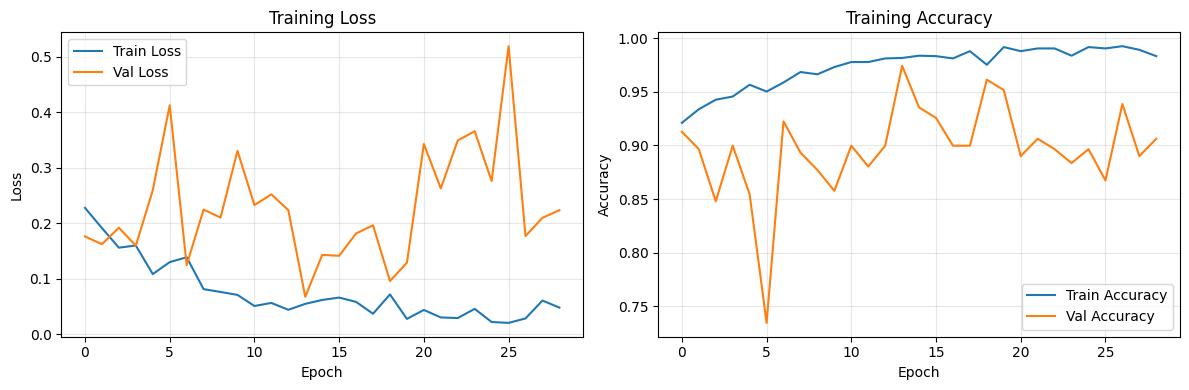

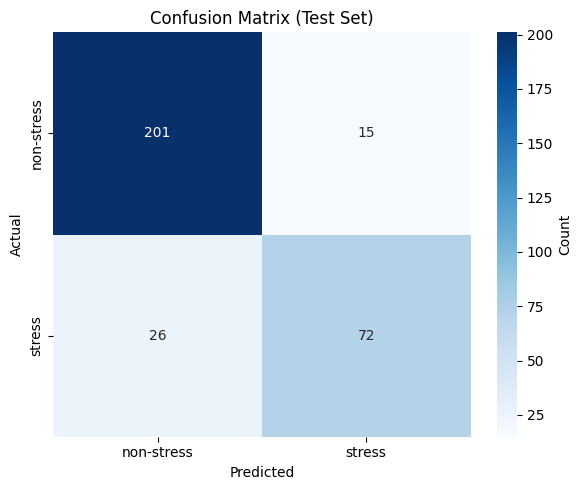


RESULTS SUMMARY
Test Accuracy:        0.8694
Balanced Accuracy:    0.8326
Weighted Precision:   0.8674
Weighted Recall:      0.8694
Weighted F1-Score:    0.8672


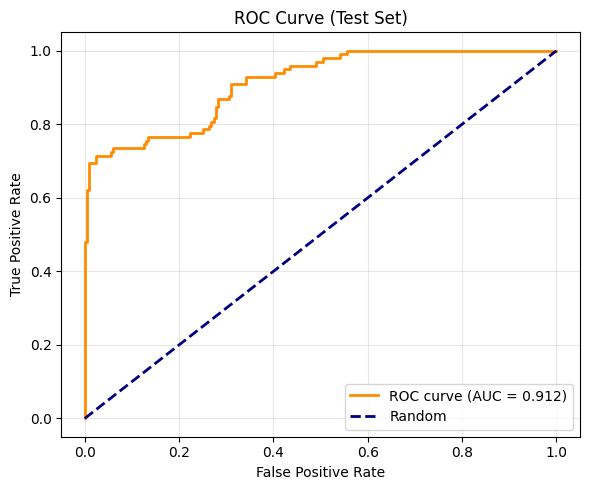

In [9]:
# 1. Training History (Loss & Accuracy)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'], label='Train Loss')
if 'val_loss' in history.history:
    axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['accuracy'], label='Train Accuracy')
if 'val_accuracy' in history.history:
    axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 2. Confusion Matrix Heatmap (on Test Set)
if len(X_test) > 0:
    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
    cm = confusion_matrix(y_test, y_pred, labels=range(N_CLASSES))
    
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Count'})
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title('Confusion Matrix (Test Set)')
    plt.tight_layout()
    plt.show()

    # 3. Summary Metrics
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
    bal_acc = balanced_accuracy_score(y_test, y_pred)
    
    print("\n" + "="*50)
    print("RESULTS SUMMARY")
    print("="*50)
    print(f"Test Accuracy:        {test_acc:.4f}")
    print(f"Balanced Accuracy:    {bal_acc:.4f}")
    print(f"Weighted Precision:   {prec:.4f}")
    print(f"Weighted Recall:      {rec:.4f}")
    print(f"Weighted F1-Score:    {f1:.4f}")
    print("="*50)

    # 4. ROC Curve (binary classification)
    if N_CLASSES == 2:
        y_proba = model.predict(X_test, verbose=0)[:, 1]  # P(stress)
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        auc = roc_auc_score(y_test, y_proba)
        fig, ax = plt.subplots(figsize=(6, 5))
        ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc:.3f})')
        ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
        ax.set_xlabel('False Positive Rate')
        ax.set_ylabel('True Positive Rate')
        ax.set_title('ROC Curve (Test Set)')
        ax.legend(loc='lower right')
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()


---

## 4. LSTM Implementation

### 4.1 Load Subject Data

Load physiological signals and labels from all subjects in the WESAD dataset.

In [12]:
# Initialize dictionaries to hold individual sensor DataFrames from ALL subjects
all_chest_dataframes = {}
all_wrist_dataframes = {}
all_quest_dataframes = {}
all_labels_data = {} # New: Dictionary to store label data for each subject

# Base path to the WESAD data directory
base_data_path = 'data/WESAD'
print(f"Base data path: {base_data_path}")
print(f"Does base path exist? {os.path.exists(base_data_path)}")

# Loop through subjects S2 to S17
print("Starting loop through subjects S2-S17...")
for subject_id in range(2, 18):
    subject_name = f'S{subject_id}'
    print(f"Looking for subject: {subject_name}")
    subject_data_path = os.path.join(base_data_path, subject_name)
    pkl_file_path = os.path.join(subject_data_path, f'{subject_name}.pkl')
    quest_file_path = os.path.join(subject_data_path, f'{subject_name}_quest.csv')

    print(f"Checking for pkl file: {pkl_file_path}")
    if os.path.exists(pkl_file_path):
        print(f"Processing {subject_name} data...")
        # Load the .pkl file
        raw_data_dict = load_subject_pickle(pkl_file_path)

        # Process 'chest' signals
        if 'chest' in raw_data_dict['signal']:
            chest_signals = raw_data_dict['signal']['chest']
            for sensor_name, data_array in chest_signals.items():
                key = f'{subject_name}_{sensor_name}'
                if sensor_name == 'ACC':
                    all_chest_dataframes[key] = pd.DataFrame(data_array, columns=['ACC_x', 'ACC_y', 'ACC_z'])
                else:
                    all_chest_dataframes[key] = pd.DataFrame(data_array.flatten(), columns=[sensor_name])

        # Process 'wrist' signals
        if 'wrist' in raw_data_dict['signal']:
            wrist_signals = raw_data_dict['signal']['wrist']
            for sensor_name, data_array in wrist_signals.items():
                key = f'{subject_name}_{sensor_name}'
                if sensor_name == 'ACC':
                    all_wrist_dataframes[key] = pd.DataFrame(data_array, columns=['ACC_x', 'ACC_y', 'ACC_z'])
                else:
                    all_wrist_dataframes[key] = pd.DataFrame(data_array.flatten(), columns=[sensor_name])

        # Extract labels
        if 'label' in raw_data_dict:
            all_labels_data[subject_name] = raw_data_dict['label']
            print(f"Loaded labels for {subject_name}")

        # Load the _quest.csv file
        if os.path.exists(quest_file_path):
            all_quest_dataframes[subject_name] = pd.read_csv(quest_file_path)
            print(f"Loaded {subject_name}_quest.csv")
        else:
            print(f"Warning: {subject_name}_quest.csv not found.")

    else:
        print(f"Warning: {subject_name}.pkl not found at {pkl_file_path}")

print("\nFinished loading data for all subjects.")
print("Total chest dataframes loaded:", len(all_chest_dataframes))
print("Total wrist dataframes loaded:", len(all_wrist_dataframes))
print("Total quest dataframes loaded:", len(all_quest_dataframes))
print("Total labels data loaded:", len(all_labels_data))

# For compatibility with subsequent cells that perform initial inspection and cleaning,
# these assignments are kept. The `chest_dataframes` and `wrist_dataframes` will be
# modified (deduplicated) by later cells.
chest_dataframes = all_chest_dataframes
wrist_dataframes = all_wrist_dataframes

# Set df_s2_quest to S10's quest data if S2 is not available for compatibility with
# existing cells that extract event timings or questionnaire responses.
if 'S2' in all_quest_dataframes:
    df_s2_quest = all_quest_dataframes['S2']
elif 'S10' in all_quest_dataframes:
    df_s2_quest = all_quest_dataframes['S10']
    print("Using S10 quest data as a fallback for df_s2_quest due to missing S2 data.")
else:
    df_s2_quest = None # Or handle error if S2 quest is essential

# Define s2_data_path for compatibility, defaulting to S10 if S2 is missing
if os.path.exists(os.path.join(base_data_path, 'S2')):
    s2_data_path = os.path.join(base_data_path, 'S2')
elif os.path.exists(os.path.join(base_data_path, 'S10')):
    s2_data_path = os.path.join(base_data_path, 'S10')
    print("Using S10 data path as a fallback for s2_data_path due to missing S2 data.")
else:
    s2_data_path = None


Base data path: data/WESAD
Does base path exist? True
Starting loop through subjects S2-S17...
Looking for subject: S2
Checking for pkl file: data/WESAD/S2/S2.pkl
Processing S2 data...
Loaded labels for S2
Loaded S2_quest.csv
Looking for subject: S3
Checking for pkl file: data/WESAD/S3/S3.pkl
Processing S3 data...
Loaded labels for S3
Loaded S3_quest.csv
Looking for subject: S4
Checking for pkl file: data/WESAD/S4/S4.pkl
Processing S4 data...
Loaded labels for S4
Loaded S4_quest.csv
Looking for subject: S5
Checking for pkl file: data/WESAD/S5/S5.pkl
Processing S5 data...
Loaded labels for S5
Loaded S5_quest.csv
Looking for subject: S6
Checking for pkl file: data/WESAD/S6/S6.pkl
Processing S6 data...
Loaded labels for S6
Loaded S6_quest.csv
Looking for subject: S7
Checking for pkl file: data/WESAD/S7/S7.pkl
Processing S7 data...
Loaded labels for S7
Loaded S7_quest.csv
Looking for subject: S8
Checking for pkl file: data/WESAD/S8/S8.pkl
Processing S8 data...
Loaded labels for S8
Loaded S

### 4.2 Resample & Align Data

Resample all sensor signals to a uniform frequency (64Hz) and align with event timings.

In [13]:
# Target frequency for resampling all sensor data
TARGET_FREQ = 64  # Hz

# Dictionary to store processed DataFrames for each subject
processed_subject_data = {}

# Original frequencies for sensors (these are hardcoded based on WESAD dataset info)
CHEST_ACC_ORIG_FREQ = 700  # Hz
CHEST_OTHER_ORIG_FREQ = 700 # ECG, EMG, EDA, Temp, Resp are also 700Hz
WRIST_ACC_ORIG_FREQ = 32   # Hz
WRIST_BVP_ORIG_FREQ = 64   # Hz
WRIST_EDA_ORIG_FREQ = 4    # Hz
WRIST_TEMP_ORIG_FREQ = 4   # Hz
LABEL_ORIG_FREQ = 700 # Labels are recorded at 700 Hz as per WESAD dataset


def resample_data(df, original_freq, target_freq, sensor_type=None):
    if df.empty:
        return df.copy()

    original_len = len(df)
    if original_len == 0:
        return df.copy()

    # Convert original_len to float for calculation to avoid integer division issues
    resample_len = int(original_len * float(target_freq) / original_freq)

    # Ensure resample_len is at least 1 if original_len > 0
    if resample_len == 0 and original_len > 0:
        resample_len = 1

    if resample_len == original_len:
        # No resampling needed if frequencies are the same
        resampled_df = df.copy()
    elif original_len > 1: # Resample only if there's enough data to resample
        resampled_data = {}
        for col in df.columns:
            if np.issubdtype(df[col].dtype, np.number):
                resampled_data[col] = resample(df[col].values, resample_len)
            else:
                # Handle non-numeric columns if necessary, for now, we'll skip or use a simple strategy
                # For WESAD, all sensor data is numeric
                pass
        resampled_df = pd.DataFrame(resampled_data, columns=df.columns)
    else:
        # If only one data point, cannot resample meaningfully, just return it
        resampled_df = df.copy()

    # Create a new TimedeltaIndex based on the target frequency
    resampled_df.index = pd.to_timedelta(np.arange(len(resampled_df)) / float(target_freq), unit='s')
    return resampled_df


print(f"Processing data for subjects to {TARGET_FREQ}Hz...")

# Iterate through each subject that has labels (indicating they were loaded successfully)
for subject_name in all_labels_data.keys():
    print(f"\n--- Processing {subject_name} ---")

    subject_chest_dataframes = {
        k.split(f'{subject_name}_')[1]: v
        for k, v in all_chest_dataframes.items()
        if k.startswith(f'{subject_name}_')
    }
    subject_wrist_dataframes = {
        k.split(f'{subject_name}_')[1]: v
        for k, v in all_wrist_dataframes.items()
        if k.startswith(f'{subject_name}_')
    }

    # Get questionnaire data for event timings (using the fallback mechanism)
    current_quest_df = all_quest_dataframes.get(subject_name)
    if current_quest_df is None:
        print(f"Warning: Questionnaire data not found for {subject_name}. Skipping event timing extraction.")
        # If no quest data, we cannot extract timings, so skip this subject or handle differently
        continue

    # --- 1. Extract Event Timings ---
    # This part is largely copied from previous logic in `pDmEu1G6BKNg` but localized
    order_str = current_quest_df.iloc[0, 0]
    start_str = current_quest_df.iloc[1, 0]
    end_str = current_quest_df.iloc[2, 0]

    def clean_split_list(s):
        parts = s.replace('#', '').split(';')
        return [p.strip() for p in parts if p.strip()]

    cleaned_order = clean_split_list(order_str)
    cleaned_start = clean_split_list(start_str)
    cleaned_end = clean_split_list(end_str)

    event_names = cleaned_order[1:]

    start_times_dict = {}
    for i, event in enumerate(event_names):
        if (i + 1) < len(cleaned_start):
            try:
                start_times_dict[event] = float(cleaned_start[i + 1])
            except ValueError:
                start_times_dict[event] = None

    end_times_dict = {}
    for i, event in enumerate(event_names):
        if (i + 1) < len(cleaned_end):
            try:
                end_times_dict[event] = float(cleaned_end[i + 1])
            except ValueError:
                end_times_dict[event] = None

    df_event_timings_subject = pd.DataFrame({
        'Event': event_names,
        'Start_Time': [start_times_dict.get(e) for e in event_names],
        'End_Time': [end_times_dict.get(e) for e in event_names]
    })
    # Convert to datetime for easier comparison and alignment
    df_event_timings_subject['Start_Time'] = pd.to_timedelta(df_event_timings_subject['Start_Time'], unit='s')
    df_event_timings_subject['End_Time'] = pd.to_timedelta(df_event_timings_subject['End_Time'], unit='s')

    # --- 2. Resample Chest Data ---
    resampled_chest_data = {}
    for sensor, df in subject_chest_dataframes.items():
        original_freq = CHEST_ACC_ORIG_FREQ if sensor == 'ACC' else CHEST_OTHER_ORIG_FREQ
        resampled_chest_data[sensor] = resample_data(df, original_freq, TARGET_FREQ)
        print(f"  Resampled chest {sensor} from {original_freq}Hz to {TARGET_FREQ}Hz. New shape: {resampled_chest_data[sensor].shape}")

    # --- 3. Resample Wrist Data ---
    resampled_wrist_data = {}
    wrist_orig_freq_map = {'ACC': WRIST_ACC_ORIG_FREQ, 'BVP': WRIST_BVP_ORIG_FREQ, 'EDA': WRIST_EDA_ORIG_FREQ, 'TEMP': WRIST_TEMP_ORIG_FREQ}
    for sensor, df in subject_wrist_dataframes.items():
        original_freq = wrist_orig_freq_map.get(sensor, TARGET_FREQ) # Default to TARGET_FREQ if not found
        resampled_wrist_data[sensor] = resample_data(df, original_freq, TARGET_FREQ)
        print(f"  Resampled wrist {sensor} from {original_freq}Hz to {TARGET_FREQ}Hz. New shape: {resampled_wrist_data[sensor].shape}")

    # --- 4. Process and Align Labels ---
    labels = all_labels_data[subject_name]
    # Labels are originally at 700Hz, we need to resample them to TARGET_FREQ

    # Create a DataFrame for labels to use the resample_data function
    df_labels_orig = pd.DataFrame(labels, columns=['label'])
    df_labels_resampled = resample_data(df_labels_orig, LABEL_ORIG_FREQ, TARGET_FREQ)
    print(f"  Resampled labels from {LABEL_ORIG_FREQ}Hz to {TARGET_FREQ}Hz. New shape: {df_labels_resampled.shape}")

    # --- 5. Consolidate and Align all data for the subject ---
    # Merge all resampled sensor dataframes and labels
    df_subject_merged = pd.DataFrame(index=pd.to_timedelta(np.arange(len(df_labels_resampled)) / float(TARGET_FREQ), unit='s'))

    # Add chest data
    for sensor, df in resampled_chest_data.items():
        # Rename columns to avoid conflicts and indicate origin
        if sensor == 'ACC':
            df_renamed = df.rename(columns={col: f'{sensor}_chest_{col}' for col in df.columns})
        else:
            df_renamed = df.rename(columns={col: f'{sensor}_chest' for col in df.columns})
        df_subject_merged = df_subject_merged.merge(df_renamed, how='outer', left_index=True, right_index=True)

    # Add wrist data
    for sensor, df in resampled_wrist_data.items():
        # Rename columns to avoid conflicts and indicate origin
        if sensor == 'ACC':
            df_renamed = df.rename(columns={col: f'{sensor}_wrist_{col}' for col in df.columns})
        else:
            df_renamed = df.rename(columns={col: f'{sensor}_wrist' for col in df.columns})
        df_subject_merged = df_subject_merged.merge(df_renamed, how='outer', left_index=True, right_index=True)

    # Add labels, ensuring they are named 'label'
    df_subject_merged = df_subject_merged.merge(df_labels_resampled, how='outer', left_index=True, right_index=True)

    # Fill any missing values after outer merge, often due to slight length differences during resampling
    # And also ensuring columns are numerical before applying fillna methods
    for col in df_subject_merged.columns:
        if pd.api.types.is_numeric_dtype(df_subject_merged[col]):
            df_subject_merged[col] = df_subject_merged[col].ffill().bfill()

    # Ensure 'label' column is integer type, as labels are discrete categories.
    # Round to nearest integer before casting, to handle floats introduced by resampling.
    if 'label' in df_subject_merged.columns and pd.api.types.is_float_dtype(df_subject_merged['label']):
        df_subject_merged['label'] = df_subject_merged['label'].round().astype(int)

    # --- Clip data to event timings ---
    # Use the 'Base' event as the primary timing reference for the overall segment
    # Assuming 'Base' is always the first event and 'Medi 2' is always the last relevant event for segmenting
    base_event_start_timedelta = df_event_timings_subject[df_event_timings_subject['Event'] == 'Base']['Start_Time'].iloc[0]
    last_event_end_timedelta = df_event_timings_subject[df_event_timings_subject['Event'] == 'Medi 2']['End_Time'].iloc[0]

    df_subject_final = df_subject_merged[
        (df_subject_merged.index >= base_event_start_timedelta) &
        (df_subject_merged.index <= last_event_end_timedelta)
    ].copy()

    processed_subject_data[subject_name] = df_subject_final
    print(f"  Final processed DataFrame for {subject_name} shape: {df_subject_final.shape}")
    print(f"  Columns for {subject_name}: {df_subject_final.columns.tolist()}")

print("\n--- All subjects processed. ---")
print("Keys in processed_subject_data:", processed_subject_data.keys())

# Display head of one processed subject's data for verification
if processed_subject_data:
    first_subject = list(processed_subject_data.keys())[0]
    print(f"\nHead of {first_subject}'s processed data:")
    print(processed_subject_data[first_subject].head())
    print(f"Info of {first_subject}'s processed data:")
    processed_subject_data[first_subject].info()


Processing data for subjects to 64Hz...

--- Processing S2 ---
  Resampled chest ACC from 700Hz to 64Hz. New shape: (389056, 3)
  Resampled chest ECG from 700Hz to 64Hz. New shape: (389056, 1)
  Resampled chest EMG from 700Hz to 64Hz. New shape: (389056, 1)
  Resampled chest EDA from 700Hz to 64Hz. New shape: (389056, 1)
  Resampled chest Temp from 700Hz to 64Hz. New shape: (389056, 1)
  Resampled chest Resp from 700Hz to 64Hz. New shape: (389056, 1)
  Resampled wrist ACC from 32Hz to 64Hz. New shape: (389056, 3)
  Resampled wrist BVP from 64Hz to 64Hz. New shape: (389056, 1)
  Resampled wrist EDA from 4Hz to 64Hz. New shape: (389056, 1)
  Resampled wrist TEMP from 4Hz to 64Hz. New shape: (389056, 1)
  Resampled labels from 700Hz to 64Hz. New shape: (389056, 1)
  Final processed DataFrame for S2 shape: (5956, 15)
  Columns for S2: ['ACC_chest_ACC_x', 'ACC_chest_ACC_y', 'ACC_chest_ACC_z', 'ECG_chest', 'EMG_chest', 'EDA_chest', 'Temp_chest', 'Resp_chest', 'ACC_wrist_ACC_x', 'ACC_wrist_AC

### 4.3 Create Windows & Standardize

Generate sliding windows from continuous data and standardize features per subject.

In [14]:
# Define parameters for windowing
WINDOW_SIZE = 256  # Number of time steps in each sequence (e.g., 4 seconds at 64Hz)
STEP_SIZE = 128     # Number of time steps to slide the window (e.g., 2 seconds overlap)

def create_windows(data, labels, window_size, step_size):
    X, y = [], []
    for i in range(0, len(data) - window_size, step_size):
        X.append(data[i:i + window_size])
        # For labels, we can take the mode, mean, or the last value in the window
        # For stress detection, often the most frequent label in the window is used
        # Or, if events are distinct, the label at the end of the window
        # Let's take the mode for simplicity for now, handling potential empty modes
        window_labels = labels[i:i+window_size]
        if len(window_labels) > 0:
            modes = pd.Series(window_labels).mode()
            if not modes.empty:
                y.append(modes.iloc[0]) # Take the first mode if multiple
            else:
                y.append(np.nan) # Handle case where no mode can be found (e.g., all nan in window)
        else:
            y.append(np.nan)

    # Filter out windows where label is NaN if they occurred
    valid_indices = ~np.isnan(y)
    X = np.array(X)[valid_indices]
    y = np.array(y)[valid_indices]

    return X, y

# Prepare data for all subjects
X_all, y_all = [], []
subject_scalers = {}

# Iterate through each subject's processed data
for subject_name, df_subject in processed_subject_data.items():
    print(f"\n--- Windowing and Scaling data for {subject_name} ---")

    # Separate features and labels
    features = df_subject.drop(columns=['label'])
    labels = df_subject['label'].values

    # Handle potential NaNs in features due to outer merge and fillna issues
    # For this specific dataset, we expect numerical data. Let's fill any remaining NaNs with 0.
    features = features.fillna(0)

    # Scale features for the current subject
    # It's important to fit the scaler only on the training data later to avoid data leakage
    # However, for now, we'll scale per subject based on their full data for consistency
    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(features)
    subject_scalers[subject_name] = scaler # Store scaler if we need to inverse transform later

    # Create windows for the current subject
    X_subject, y_subject = create_windows(scaled_features, labels, WINDOW_SIZE, STEP_SIZE)

    if X_subject.size > 0:
        X_all.append(X_subject)
        y_all.append(y_subject)
        print(f"  Created {len(X_subject)} windows for {subject_name}")
    else:
        print(f"  No valid windows created for {subject_name}")

# Concatenate all subjects' data
if X_all and y_all:
    X_combined = np.vstack(X_all)
    y_combined = np.concatenate(y_all)
    print(f"\nCombined data from all subjects: X_combined shape {X_combined.shape}, y_combined shape {y_combined.shape}")

    # Split data into training and testing sets
    # We'll need to decide on a robust splitting strategy, e.g., subject-wise split or time-based split
    # For a simple start, let's do a random split on combined windows
    X_train, X_test, y_train, y_test = train_test_split(X_combined, y_combined, test_size=0.2, random_state=42, stratify=y_combined)

    print(f"\nTraining data shape: {X_train.shape}, {y_train.shape}")
    print(f"Testing data shape: {X_test.shape}, {y_test.shape}")

    # Display unique labels and their counts to check stratification
    unique_labels, counts = np.unique(y_train, return_counts=True)
    print(f"Training label distribution: {dict(zip(unique_labels, counts))}")
    unique_labels, counts = np.unique(y_test, return_counts=True)
    print(f"Testing label distribution: {dict(zip(unique_labels, counts))}")

else:
    print("No data available after processing subjects to create combined dataset.")



--- Windowing and Scaling data for S2 ---
  Created 45 windows for S2

--- Windowing and Scaling data for S3 ---
  Created 47 windows for S3

--- Windowing and Scaling data for S4 ---
  Created 47 windows for S4

--- Windowing and Scaling data for S5 ---
  Created 45 windows for S5

--- Windowing and Scaling data for S6 ---
  Created 51 windows for S6

--- Windowing and Scaling data for S7 ---
  Created 40 windows for S7

--- Windowing and Scaling data for S8 ---
  Created 41 windows for S8

--- Windowing and Scaling data for S9 ---
  Created 40 windows for S9

--- Windowing and Scaling data for S10 ---
  Created 42 windows for S10

--- Windowing and Scaling data for S11 ---
  Created 40 windows for S11

--- Windowing and Scaling data for S13 ---
  Created 42 windows for S13

--- Windowing and Scaling data for S14 ---
  Created 32 windows for S14

--- Windowing and Scaling data for S15 ---
  Created 40 windows for S15

--- Windowing and Scaling data for S16 ---
  Created 43 windows fo

### 4.4 Build & Train LSTM Model

Define and train a multi-layer LSTM model for sequence classification.

In [15]:
# Assuming y_train and y_test contain integer labels, but they might not be 0-indexed
# First, let's map the labels to a 0-indexed range
# Identify unique labels and map them
all_unique_labels = np.unique(y_combined)
label_mapping = {label: i for i, label in enumerate(all_unique_labels)}

y_train_mapped = np.array([label_mapping[label] for label in y_train])
y_test_mapped = np.array([label_mapping[label] for label in y_test])

# Convert integer labels to one-hot encoded vectors
num_classes = len(all_unique_labels)
y_train_one_hot = to_categorical(y_train_mapped, num_classes=num_classes)
y_test_one_hot = to_categorical(y_test_mapped, num_classes=num_classes)

# Define the LSTM model
model = keras.Sequential([
    layers.LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=True),
    layers.Dropout(0.3),
    layers.LSTM(64),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax') # Output layer for multi-class classification
])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Display model summary
print("\n--- LSTM Model Summary ---")
model.summary()

# Train the model
print("\n--- Training LSTM Model ---")
history = model.fit(
    X_train,
    y_train_one_hot,
    epochs=20, # You might want to adjust the number of epochs
    batch_size=32,
    validation_split=0.2, # Use a portion of training data for validation
    callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]
)

# Evaluate the model
print("\n--- Evaluating LSTM Model ---")
loss, accuracy = model.evaluate(X_test, y_test_one_hot, verbose=1)
print(f'Test Loss: {loss:.4f}')
print(f'Test Accuracy: {accuracy:.4f}')

# Store metrics for potential future use or plotting
lstm_history = history
lstm_test_loss = loss
lstm_test_accuracy = accuracy



--- LSTM Model Summary ---


/Users/erichernandez/Projects/Jupyter Notebooks/aai_530_final_project_group_4/.venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 256, 64)        │        20,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,378 (208.51 KB)

 Trainable params: 53,378 (208.51 KB)

 Non-trainable params: 0 (0.00 B)


--- Training LSTM Model ---
Epoch 1/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 149ms/step - accuracy: 0.7604 - loss: 0.5545 - val_accuracy: 0.9223 - val_loss: 0.3324
Epoch 2/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - accuracy: 0.9658 - loss: 0.1720 - val_accuracy: 0.9417 - val_loss: 0.1733
Epoch 3/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 112ms/step - accuracy: 0.9829 - loss: 0.0831 - val_accuracy: 0.9806 - val_loss: 0.0870
Epoch 4/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - accuracy: 0.9804 - loss: 0.0596 - val_accuracy: 0.9903 - val_loss: 0.0726
Epoch 5/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step - accuracy: 0.9878 - loss: 0.0375 - val_accuracy: 0.9903 - val_loss: 0.0470
Epoch 6/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step - accuracy: 0.9902 - loss: 0.0286 - val_accuracy: 0.9903 - val_loss: 0.0175
Epoch 7/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step - accuracy: 0.9976 - loss: 0.0095 - val_accuracy: 1.0000 - val_loss: 0.0101
Epoch 8/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step - accuracy: 1.0000 - lo

---

## 5. XGBoost Implementation

### 5.1 Helper Functions

Define utility functions for windowing, feature extraction, and label processing.

In [16]:
def create_windows(
    signal: np.ndarray, window_size: int, step_size: int
) -> list[np.ndarray]:
    """Create sliding windows from a physiological signal.
    
    Args:
        signal: 1D numpy array containing physiological sensor data.
        window_size: Number of samples in each window.
        step_size: Number of samples to slide the window forward.
        
    Returns:
        List of numpy arrays, where each array is a window of the signal.
    """
    windows = [
        signal[i:i + window_size]
        for i in range(0, len(signal) - window_size, step_size)
    ]
    
    return windows


In [17]:
def get_window_labels(
    labels: np.ndarray, window_size: int, step_size: int
) -> list[int]:
    """Extract majority-vote labels for time windows with binary classification.

    Args:
        labels: 1D numpy array of ground truth labels (0=transient, 1=baseline,
            2=stress, 3=amusement).
        window_size: Number of samples in each window.
        step_size: Number of samples to slide the window forward.
        
    Returns:
        List of binary labels where 1 indicates stress and 0 indicates non-stress.
        Windows with only transient labels are excluded.
    """
    y: list[int] = []

    for i in range(0, len(labels) - window_size, step_size):
        window = labels[i:i + window_size]

         # Remove transient labels
        window = window[window != 0]

        if len(window) == 0:
            continue

        majority = np.bincount(window).argmax()

        if majority == 2:
            # Stress
            y.append(1)
        elif majority in [1, 3]:
            # Non-stress
            y.append(0)
        else:
            continue

    return y


In [18]:
def extract_features(window: np.ndarray) -> list[float]:
    """Extract statistical features from a signal window.

    Args:
        window: 1D numpy array containing signal samples from a time window.
        
    Returns:
        List of 7 floating-point statistical features: mean, standard deviation,
        minimum, maximum, 25th percentile, 75th percentile, and median.
    """
    features: list[float] = [
        float(np.mean(window)),
        float(np.std(window)),
        float(np.min(window)),
        float(np.max(window)),
        float(np.percentile(window, 25)),
        float(np.percentile(window, 75)),
        float(np.median(window))
    ]
    
    return features


In [19]:
def process_subject(
    subject_path: str, window_size: int, step_size: int
) -> tuple[list[list[float]], list[int]]:
    """Process a single subject's data through the complete feature extraction pipeline.
    
    Args:
        subject_path: Path to the subject's pickle file.
        window_size: Number of samples in each time window.
        step_size: Number of samples to slide the window forward.
        
    Returns:
        Tuple containing:
            - Feature matrix (list of feature vectors), where each feature vector
              contains 56 floats (7 features × 8 sensor channels).
            - Labels (list of integers), where 1 indicates stress and 0 indicates
              non-stress.
    """
    subject_data = load_subject_pickle(subject_path)

    chest = subject_data["signal"]["chest"]
    labels = subject_data["label"]

    ecg = chest["ECG"]
    eda = chest["EDA"]
    resp = chest["Resp"]
    temp = chest["Temp"]
    emg = chest["EMG"]
    acc = chest["ACC"]  # shape: (n_samples, 3)

    # Handle ACC channels separately
    acc_x = acc[:, 0]
    acc_y = acc[:, 1]
    acc_z = acc[:, 2]

    ecg_w = create_windows(ecg, window_size, step_size)
    eda_w = create_windows(eda, window_size, step_size)
    resp_w = create_windows(resp, window_size, step_size)
    temp_w = create_windows(temp, window_size, step_size)
    emg_w = create_windows(emg, window_size, step_size)

    # Create windows for each ACC channel
    acc_x_w = create_windows(acc_x, window_size, step_size)
    acc_y_w = create_windows(acc_y, window_size, step_size)
    acc_z_w = create_windows(acc_z, window_size, step_size)

    y = get_window_labels(labels, window_size, step_size)

    X: list[list[float]] = []
    valid_len = min(len(y), len(ecg_w))

    for i in range(valid_len):
        features: list[float] = []
        
        features += extract_features(ecg_w[i])
        features += extract_features(eda_w[i])
        features += extract_features(resp_w[i])
        features += extract_features(temp_w[i])
        features += extract_features(emg_w[i])

        features += extract_features(acc_x_w[i])
        features += extract_features(acc_y_w[i])
        features += extract_features(acc_z_w[i])

        X.append(features)

    return X, y[:valid_len]


### 5.2 Feature Extraction Pipeline

Process all subjects and extract statistical features from chest sensor signals.

In [20]:
DATASET_PATH: str = 'data/WESAD'

# Sampling frequency and window parameters
SAMPLING_RATE_HZ: int = 700
WINDOW_SEC: int = 60
WINDOW_SIZE: int = SAMPLING_RATE_HZ * WINDOW_SEC
STEP_SIZE: int = WINDOW_SIZE // 2  # 50% overlap

all_X: list[list[float]] = []
all_y: list[int] = []
all_subject_ids: list[str] = []

subjects: list[str] = sorted([
    d for d in os.listdir(DATASET_PATH)
    if d.startswith("S")
])

for subject in subjects:
    subject_path: str = os.path.join(DATASET_PATH, subject, f"{subject}.pkl")

    if not os.path.exists(subject_path):
        continue

    print(f"Processing {subject}...")
    X, y = process_subject(subject_path, WINDOW_SIZE, STEP_SIZE)

    all_X.extend(X)
    all_y.extend(y)
    all_subject_ids.extend([subject] * len(y))


Processing S10...
Processing S11...
Processing S13...
Processing S14...
Processing S15...
Processing S16...
Processing S17...
Processing S2...
Processing S3...
Processing S4...
Processing S5...
Processing S6...
Processing S7...
Processing S8...
Processing S9...


### 5.3 Create Feature DataFrame

Organize extracted features into a structured DataFrame for model training.

In [21]:
columns: list[str] = [
    "ECG_mean", "ECG_std", "ECG_min", "ECG_max", "ECG_25th", "ECG_75th", "ECG_median",
    "EDA_mean", "EDA_std", "EDA_min", "EDA_max", "EDA_25th", "EDA_75th", "EDA_median",
    "RESP_mean", "RESP_std", "RESP_min", "RESP_max", "RESP_25th", "RESP_75th", "RESP_median",
    "TEMP_mean", "TEMP_std", "TEMP_min", "TEMP_max", "TEMP_25th", "TEMP_75th", "TEMP_median",
    "EMG_mean", "EMG_std", "EMG_min", "EMG_max", "EMG_25th", "EMG_75th", "EMG_median",
    "ACC_X_mean", "ACC_X_std", "ACC_X_min", "ACC_X_max", "ACC_X_25th", "ACC_X_75th", "ACC_X_median",
    "ACC_Y_mean", "ACC_Y_std", "ACC_Y_min", "ACC_Y_max", "ACC_Y_25th", "ACC_Y_75th", "ACC_Y_median",
    "ACC_Z_mean", "ACC_Z_std", "ACC_Z_min", "ACC_Z_max", "ACC_Z_25th", "ACC_Z_75th", "ACC_Z_median"
]

df: pd.DataFrame = pd.DataFrame(all_X, columns=columns)
df["label"] = all_y
df["subject"] = all_subject_ids

df.describe()


,ECG_mean,ECG_std,ECG_min,ECG_max,ECG_25th,ECG_75th,ECG_median,EDA_mean,EDA_std,EDA_min,...,ACC_Y_75th,ACC_Y_median,ACC_Z_mean,ACC_Z_std,ACC_Z_min,ACC_Z_max,ACC_Z_25th,ACC_Z_75th,ACC_Z_median,label
count,1189.000000,1189.000000,1189.000000,1189.000000,1189.000000,1189.000000,1189.000000,1189.000000,1189.000000,1189.000000,...,1189.000000,1189.000000,1189.000000,1189.000000,1189.000000,1189.000000,1189.000000,1189.000000,1189.000000,1189.000000
mean,0.001082,0.258495,-0.631291,1.427160,-0.093443,0.034790,-0.026941,4.223885,0.058185,3.984789,...,-0.029094,-0.045952,-0.278389,0.061842,-0.468194,-0.026152,-0.317691,-0.243988,-0.280571,0.304458
std,0.000507,0.061374,0.237107,0.190688,0.041020,0.032576,0.023404,3.021945,0.146955,2.975364,...,0.107106,0.107300,0.295288,0.072158,0.345320,0.480285,0.288954,0.320619,0.305060,0.460371
min,-0.001824,0.111402,-1.499680,0.744095,-0.334030,-0.017624,-0.105698,0.728551,0.007825,0.416183,...,-0.469000,-0.474200,-0.942175,0.004229,-4.779800,-0.918000,-0.945400,-0.939400,-0.942200,0.000000
25%,0.000851,0.230485,-0.777649,1.497299,-0.111511,0.012051,-0.042892,1.684937,0.013500,1.485062,...,-0.060400,-0.073800,-0.439890,0.014636,-0.601400,-0.338800,-0.477000,-0.429600,-0.448800,0.000000
50%,0.001138,0.259799,-0.578384,1.499222,-0.087204,0.025131,-0.029251,3.093501,0.018515,2.884674,...,-0.016200,-0.030600,-0.272959,0.031858,-0.447800,-0.031800,-0.321800,-0.232600,-0.281000,0.000000
75%,0.001379,0.292022,-0.446732,1.499451,-0.070965,0.048809,-0.019180,6.219160,0.039984,5.997086,...,0.027000,0.011000,-0.120819,0.078681,-0.303200,0.204600,-0.169800,-0.067000,-0.122600,1.000000
max,0.004007,0.476084,-0.241104,1.499954,0.001144,0.186916,0.037033,14.134826,2.517641,12.770844,...,0.248650,0.213200,0.735563,0.577842,0.665000,4.508200,0.719400,0.766600,0.731000,1.000000


### 5.4 Train/Test Split & Scaling

Split data by subject and standardize features using training set statistics.

In [22]:
test_subjects: list[str] = ["S15", "S16", "S17"]
train_subjects: list[str] = [s for s in subjects if s not in test_subjects]

# Print train/test split info
print(f"Train subjects: {train_subjects}")
print(f"Test subjects: {test_subjects}")

train_df: pd.DataFrame = df[df["subject"].isin(train_subjects)]
test_df: pd.DataFrame = df[df["subject"].isin(test_subjects)]

X_train: pd.DataFrame = train_df.drop(["label", "subject"], axis=1)
y_train: pd.Series = train_df["label"]

X_test: pd.DataFrame = test_df.drop(["label", "subject"], axis=1)
y_test: pd.Series = test_df["label"]

# Standardize features using training set statistics
scaler: StandardScaler = StandardScaler()
X_train_scaled: np.ndarray = scaler.fit_transform(X_train)
X_test_scaled: np.ndarray = scaler.transform(X_test)


Train subjects: ['S10', 'S11', 'S13', 'S14', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9']
Test subjects: ['S15', 'S16', 'S17']


### 5.5 Hyperparameter Tuning

Use RandomizedSearchCV to find optimal XGBoost hyperparameters.

In [23]:
model: XGBClassifier = XGBClassifier(
    eval_metric='logloss',
    random_state=42,
)

parameters_xgb: dict[str, list[int] | list[float]] = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, 8],
    'learning_rate': [0.05, 0.1, 0.2]
}

model_optimized: RandomizedSearchCV = RandomizedSearchCV(
    model,
    parameters_xgb,
    n_iter=5,
    cv=3,
    random_state=42
)

model_optimized.fit(
    X_train_scaled, 
    y_train
)


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'learning_rate': [0.05, 0.1, ...], 'max_depth': [3, 5, ...], 'n_estimators': [50, 100, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default 

### 5.6 Evaluate XGBoost Model

Generate predictions and evaluate model performance on the test set.

In [24]:
# --- Predictions ---
predictions = model_optimized.predict(X_test_scaled)

# --- Core Metrics ---
accuracy = accuracy_score(y_test, predictions)
precision = precision_score(y_test, predictions, pos_label=1)
recall = recall_score(y_test, predictions, pos_label=1)
f1 = f1_score(y_test, predictions, pos_label=1)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

# --- Detailed Report ---
print("\nClassification Report:")
print(classification_report(y_test, predictions, target_names=["Non-Stress", "Stress"], digits=4))



Accuracy : 0.7291666666666666
Precision: 0.6470588235294118
Recall   : 0.29333333333333333
F1 Score : 0.4036697247706422

Classification Report:
              precision    recall  f1-score   support

  Non-Stress     0.7427    0.9273    0.8248       165
      Stress     0.6471    0.2933    0.4037        75

    accuracy                         0.7292       240
   macro avg     0.6949    0.6103    0.6142       240
weighted avg     0.7128    0.7292    0.6932       240



---

## 6. Results & Comparison

### Summary

This notebook implemented three approaches for stress detection:

1. **1D-CNN**: Uses temporal convolutions on raw BVP/EDA signals from wrist sensors
   - Advantages: No feature engineering, captures temporal patterns
   - Disadvantages: Requires more data, less interpretable

2. **LSTM**: Processes multi-sensor sequences with recurrent layers
   - Advantages: Handles variable-length sequences, captures long-term dependencies
   - Disadvantages: Computationally expensive, requires careful tuning

3. **XGBoost**: Uses hand-crafted statistical features from chest sensors
   - Advantages: Fast training, interpretable features, good with limited data
   - Disadvantages: Requires domain knowledge for feature engineering

### Model Comparison

Each model demonstrates different trade-offs:
- **Data requirements**: Raw signals (CNN/LSTM) vs. engineered features (XGBoost)
- **Computational complexity**: Deep learning vs. gradient boosting
- **Interpretability**: Black-box neural nets vs. feature-based models
- **Sensor requirements**: Wrist-only (CNN) vs. chest-worn (XGBoost/LSTM)